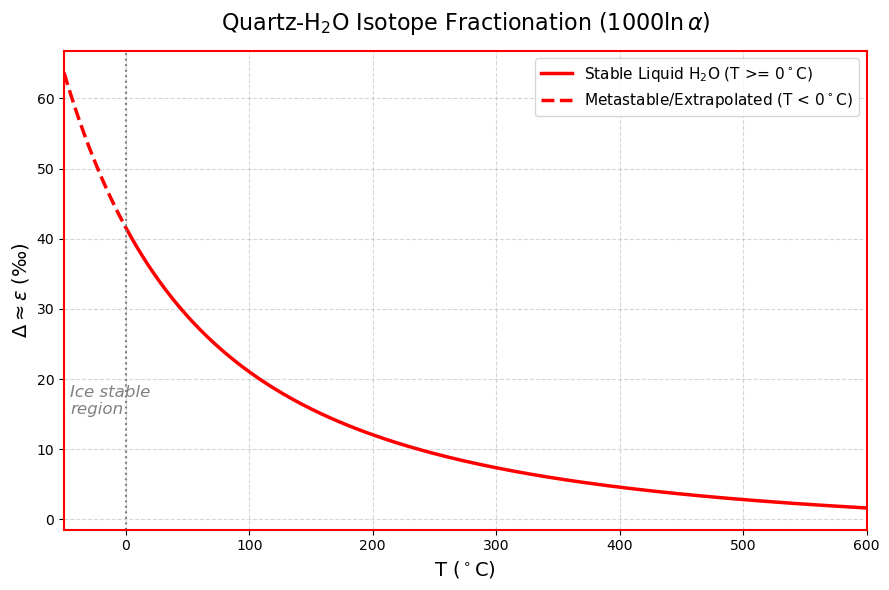

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 分段定义温度范围
T_c_liquid = np.linspace(0, 600, 400)    # 0 到 600度 (真实液态水区)
T_c_subzero = np.linspace(-50, 0, 100)   # -50 到 0度 (假想过冷水/理论外推区)

# 2. 转换为开尔文温度
T_k_liquid = T_c_liquid + 273.15
T_k_subzero = T_c_subzero + 273.15

# 3. 计算 1000 ln(alpha)
# 公式: 1000ln(α) = 3.306 * (10^6 / T^2) - 2.71
delta_liquid = 3.306 * (1e6 / T_k_liquid**2) - 2.71
delta_subzero = 3.306 * (1e6 / T_k_subzero**2) - 2.71

# 4. 开始绘图
plt.figure(figsize=(9, 6))

# 绘制 0℃ 以上的实线 (真实有效范围)，【修复点1】将 \ge 改为纯文本 >= 彻底避免报错
plt.plot(T_c_liquid, delta_liquid, color='red', linewidth=2.5, 
         label=r'Stable Liquid H$_2$O (T >= 0$^\circ$C)')

# 绘制 0℃ 以下的虚线 (理论外推范围)
plt.plot(T_c_subzero, delta_subzero, color='red', linewidth=2.5, linestyle='--', 
         label=r'Metastable/Extrapolated (T < 0$^\circ$C)')

# 添加 0℃ 的辅助线，强调相变界限
plt.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
plt.text(-45, 15, 'Ice stable\nregion', color='gray', fontsize=12, style='italic')

# 设置坐标轴范围
plt.xlim(-50, 600)

# 添加网格
plt.grid(True, linestyle='--', alpha=0.5)

# 设置坐标轴标签
plt.xlabel(r'T ($^\circ$C)', fontsize=14)
# 【修复点2】将 LaTeX 字符串与千分号分离，避免部分字体的千分号渲染报错
plt.ylabel(r'$\Delta \approx \varepsilon$ ' + '(‰)', fontsize=14)

# 将边框标红，贴合 PPT 红框风格
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color('red')
    spine.set_linewidth(1.5)

# 增加标题和图例
plt.title(r'Quartz-H$_2$O Isotope Fractionation ($1000\ln\alpha$)', fontsize=16, pad=15)
plt.legend(fontsize=11)

# 自动调整布局，现在可以安全使用了
plt.tight_layout()

# 显示图像
plt.show()